In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [3]:
dataset = ImageFolder(
    root="/home/nathiskar/potato_diseases/archive(2)/PlantVillage",
    transform=None
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [4]:
print(dataset.classes)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [5]:
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

In [6]:
train_subset, val_subset, test_subset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [9]:
class TransformSubset:
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]
        image = self.transform(image)
        return image, label

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, val_test_transform)
test_dataset = TransformSubset(test_subset, test_transform)


In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, prefetch_factor=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, prefetch_factor=2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


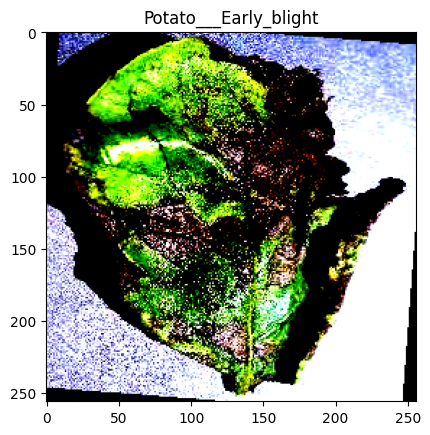

In [13]:
for image_batch, label_batch in train_loader:
    image = image_batch[0].permute(1, 2, 0)
    plt.imshow(image)
    plt.title(dataset.classes[label_batch[0]])
    plt.show()
    break


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE)

In [16]:
class Pmodel(nn.Module):
    def __init__(self, num_classes):
        super(Pmodel, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
num_classes = len(dataset.classes)
model = Pmodel(num_classes).to(device)

print(model)

Pmodel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
train_accuracies = []
val_accuracies = []

train_losses = []
val_losses = []


for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_correct = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        predicted = model(images)
        loss = criterion(predicted, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(predicted, 1)
        train_correct += (predicted == labels).sum().item()
    
    train_accuracy = train_correct / len(train_dataset)
    train_losses.append(train_loss/ len(train_loader))
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            predicted = model(images)
            loss = criterion(predicted, labels)

            val_loss += loss.item()
            _, predicted = torch.max(predicted, 1)
            val_correct += (predicted == labels).sum().item()

    val_accuracy = val_correct / len(val_dataset)

    val_losses.append(val_loss/len(val_loader))
    val_accuracies.append(val_accuracy)

    
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss/len(train_loader):.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss/len(val_loader):.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )
    




Epoch [1/50] Train Loss: 0.7514 Train Acc: 0.6490 Val Loss: 0.5847 Val Acc: 0.7907
Epoch [2/50] Train Loss: 0.6238 Train Acc: 0.7414 Val Loss: 0.4458 Val Acc: 0.8465
Epoch [3/50] Train Loss: 0.4293 Train Acc: 0.8234 Val Loss: 0.3119 Val Acc: 0.8419
Epoch [4/50] Train Loss: 0.2875 Train Acc: 0.8762 Val Loss: 0.0972 Val Acc: 0.9674
Epoch [5/50] Train Loss: 0.1454 Train Acc: 0.9471 Val Loss: 0.0851 Val Acc: 0.9721
Epoch [6/50] Train Loss: 0.1466 Train Acc: 0.9436 Val Loss: 0.0685 Val Acc: 0.9814
Epoch [7/50] Train Loss: 0.1386 Train Acc: 0.9494 Val Loss: 0.0714 Val Acc: 0.9721
Epoch [8/50] Train Loss: 0.1232 Train Acc: 0.9506 Val Loss: 0.0630 Val Acc: 0.9767
Epoch [9/50] Train Loss: 0.0945 Train Acc: 0.9558 Val Loss: 0.1295 Val Acc: 0.9442
Epoch [10/50] Train Loss: 0.1544 Train Acc: 0.9465 Val Loss: 0.0620 Val Acc: 0.9814
Epoch [11/50] Train Loss: 0.1134 Train Acc: 0.9524 Val Loss: 0.0994 Val Acc: 0.9628
Epoch [12/50] Train Loss: 0.0943 Train Acc: 0.9704 Val Loss: 0.0705 Val Acc: 0.9674
E

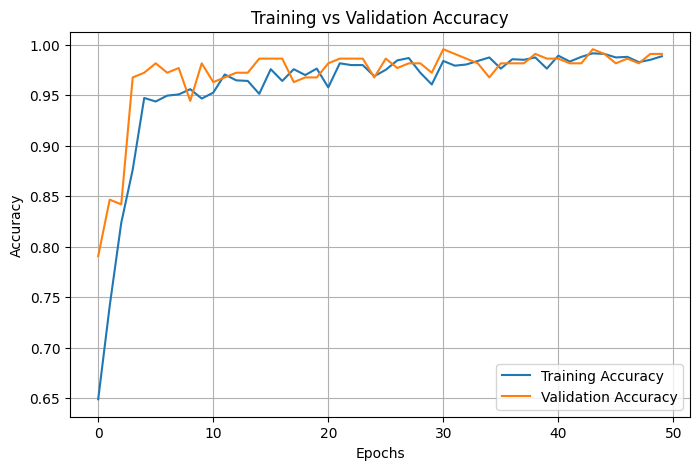

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

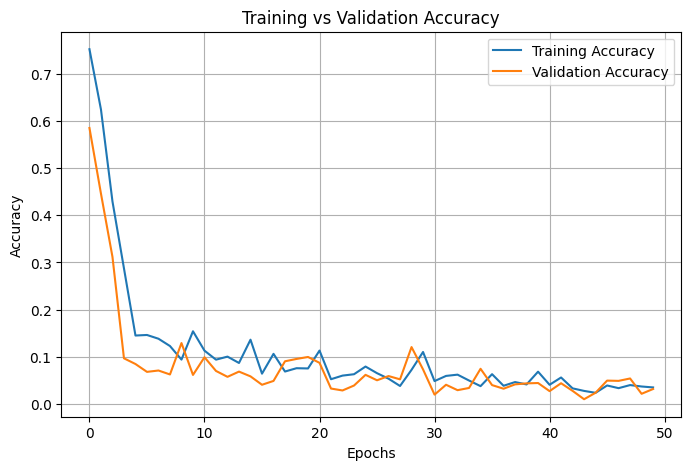

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Accuracy")
plt.plot(val_losses, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
torch.save(model.state_dict(), "model_0.1.pth")